# Icosahedral Global Graph - Internals of `weather-model-graphs`

This notebook explains *how* `weather-model-graphs` constructs icosahedral graphs under the hood,
following the sequence of steps that `create_all_graph_components()` executes internally:

**A. Node coordinates**
1. Icosahedral mesh generation - trimesh subdivision on the unit sphere
2. Coordinate representation - Cartesian <-> lat/lon conversions

**B. Connectivity**
3. Face-adjacent mesh edges - every node gets exactly 5 or 6 neighbours
4. Grid-to-mesh (G2M) - radius-based search from grid points to mesh nodes
5. Mesh-to-grid (M2G) - containing-triangle lookup with barycentric weights

**C. Scaling**
6. Performance - how node and face counts grow with subdivision level

Familiarity with the user-facing API is assumed; see `icosahedral_global_graph_usage.ipynb` for that.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial import cKDTree

from weather_model_graphs.create.mesh.layouts.icosahedral import (
    create_hierarchy_of_icosahedral_meshes,
    generate_icosahedral_mesh,
    connect_grid_to_mesh,
    lat_lon_to_cartesian,
    cartesian_to_lat_lon,
    barycentric_coordinates,
)

## Setup: sample grid and mesh

We use a 2.5deg global grid and a level-**2** mesh throughout - small enough to render quickly
while clearly showing the structure.  (Increase `refinement_level` to 3+ in a real workflow.)


In [34]:
resolution = 2.5
lats = np.arange(-90, 90.1, resolution)
lons = np.arange(-180, 180.1, resolution)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing="ij")
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])

REFINEMENT = 2
mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions=REFINEMENT)
finest_vertices, finest_faces = mesh_list[-1]
g2m_edges = connect_grid_to_mesh(
    grid_lat_lon, finest_vertices, finest_faces, radius_factor=0.6
)

print(f"Grid       : {len(grid_lat_lon)} points")
print(
    f"Mesh level {REFINEMENT}: {len(finest_vertices)} vertices, {len(finest_faces)} faces"
)
print(f"G2M edges  : {g2m_edges.shape[1]}")

Grid       : 10585 points
Mesh level 2: 162 vertices, 320 faces
G2M edges  : 16081


---
## A. Node coordinates


### 1. Icosahedral mesh generation

`generate_icosahedral_mesh(refinement_level)` starts from a regular icosahedron (12 vertices,
20 triangular faces) and repeatedly bisects every edge, projecting new midpoints onto the unit
sphere.  Each subdivision multiplies the face count by 4 and the vertex count by approximately 4.

The 3-D plot below verifies that all vertices lie on the unit sphere and that subdivision is uniform.


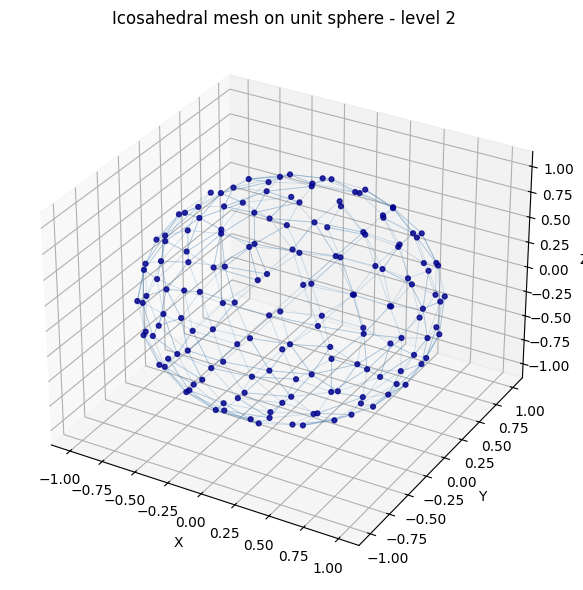

All vertices on unit sphere: True


In [35]:
vertices, faces = generate_icosahedral_mesh(refinement_level=REFINEMENT)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Draw a random subset of faces so the plot stays readable
rng = np.random.default_rng(0)
sample_faces = faces[rng.choice(len(faces), size=min(200, len(faces)), replace=False)]
for face in sample_faces:
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        ax.plot3D(
            *zip(vertices[face[i]], vertices[face[j]]),
            color="steelblue",
            alpha=0.25,
            linewidth=0.6,
        )

ax.scatter(*vertices.T, c="darkblue", s=12, alpha=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Icosahedral mesh on unit sphere - level {REFINEMENT}")
plt.tight_layout()
plt.show()
print(
    f"All vertices on unit sphere: {np.allclose(np.linalg.norm(vertices, axis=1), 1.0)}"
)

### 2. Coordinate representation - Cartesian <-> lat/lon

Internally the mesh works in Cartesian (x, y, z) coordinates on the unit sphere.
`cartesian_to_lat_lon` and `lat_lon_to_cartesian` convert between the two representations;
the round-trip below confirms the conversion is lossless.


In [36]:
# Round-trip: Cartesian to lat/lon to Cartesian
lat_lon = cartesian_to_lat_lon(vertices)
vertices_back = lat_lon_to_cartesian(lat_lon[:, 0], lat_lon[:, 1])
print(f"Max round-trip error: {np.max(np.abs(vertices - vertices_back)):.2e}")

# Quick sanity check on the lat/lon ranges
lat, lon = lat_lon[:, 0], lat_lon[:, 1]
print(f"Latitude  range: [{lat.min():.1f}, {lat.max():.1f}]")
print(f"Longitude range: [{lon.min():.1f}, {lon.max():.1f}]")

Max round-trip error: 4.44e-16
Latitude  range: [-90.0, 90.0]
Longitude range: [-167.1, 180.0]


---
## B. Connectivity


### 3. Face-adjacent mesh edges (M2M)

Every mesh node connects to exactly **5 or 6** face-adjacent neighbours:

- **6 neighbours** - all nodes except the 12 original icosahedron vertices.
- **5 neighbours** - the 12 vertices inherited from the base icosahedron (one per "pentagonal" patch).

Connectivity is determined entirely by the triangulation faces - no pattern kwarg needed.
The interactive plot below colours nodes by their degree and highlights one node and its neighbours.


In [37]:
vertices, faces = generate_icosahedral_mesh(
    refinement_level=1
)  # level 1 is easiest to inspect
lat_lon = cartesian_to_lat_lon(vertices)
lat, lon = lat_lon[:, 0], lat_lon[:, 1]

# Collect unique edges and compute degree
edges = set()
for f in faces:
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        edges.add((min(f[i], f[j]), max(f[i], f[j])))

degree = np.zeros(len(vertices), dtype=int)
for e in edges:
    degree[e[0]] += 1
    degree[e[1]] += 1

print(f"Nodes with 5 neighbours (icosahedral vertices): {(degree == 5).sum()}")
print(f"Nodes with 6 neighbours (regular nodes)       : {(degree == 6).sum()}")

# Build edge traces, masking antimeridian-crossing edges
edge_lons, edge_lats = [], []
for e in edges:
    if abs(lon[e[0]] - lon[e[1]]) < 180:
        edge_lons += [lon[e[0]], lon[e[1]], None]
        edge_lats += [lat[e[0]], lat[e[1]], None]

# Pick an equatorial degree-6 node to highlight
highlight = next(i for i in range(len(vertices)) if degree[i] == 6 and abs(lat[i]) < 20)
neighbours = [e[1] if e[0] == highlight else e[0] for e in edges if highlight in e]

hl_lons, hl_lats = [], []
for n in neighbours:
    if abs(lon[n] - lon[highlight]) < 180:
        hl_lons += [lon[highlight], lon[n], None]
        hl_lats += [lat[highlight], lat[n], None]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=edge_lons,
        y=edge_lats,
        mode="lines",
        line=dict(color="steelblue", width=1),
        opacity=0.4,
        name="face-adjacent edges",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=lon[degree == 6],
        y=lat[degree == 6],
        mode="markers",
        marker=dict(size=9, color="cornflowerblue", line=dict(color="white", width=1)),
        name="6 neighbours (regular)",
    )
)
fig.add_trace(
    go.Scatter(
        x=lon[degree == 5],
        y=lat[degree == 5],
        mode="markers",
        marker=dict(size=9, color="tomato", line=dict(color="white", width=1)),
        name="5 neighbours (icosahedral vertex)",
    )
)
fig.add_trace(
    go.Scatter(
        x=hl_lons,
        y=hl_lats,
        mode="lines",
        line=dict(color="gold", width=3),
        name=f"example node: {degree[highlight]} neighbours",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=[lon[highlight]],
        y=[lat[highlight]],
        mode="markers",
        marker=dict(size=15, color="gold", line=dict(color="black", width=2)),
        name="example node",
    )
)
fig.update_layout(
    title="Face-adjacent connectivity - refinement level 1",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    xaxis=dict(range=[-185, 185]),
    yaxis=dict(range=[-95, 95]),
    width=1000,
    height=580,
)
fig.show()

Nodes with 5 neighbours (icosahedral vertices): 12
Nodes with 6 neighbours (regular nodes)       : 30


### 4. Grid-to-mesh connectivity (G2M)

Each grid point is connected to every mesh node within a search radius that is proportional
to the typical mesh edge length (`radius_factor × max_edge_length`).  This is computed via
a 3-D k-d tree on the unit sphere.

The plot below zooms into a small region to show how several grid points (green squares) each
connect to the nearest mesh nodes (blue circles).


In [38]:
vertices, faces = generate_icosahedral_mesh(refinement_level=REFINEMENT)
lat_lon_mesh = cartesian_to_lat_lon(vertices)
lat_m, lon_m = lat_lon_mesh[:, 0], lat_lon_mesh[:, 1]

# Focus on a small region around (20N, 10E)
focus_lat, focus_lon, pad = 20.0, 10.0, 15.0
region_mask = (
    (grid_lat_lon[:, 0] > focus_lat - pad)
    & (grid_lat_lon[:, 0] < focus_lat + pad)
    & (grid_lat_lon[:, 1] > focus_lon - pad)
    & (grid_lat_lon[:, 1] < focus_lon + pad)
)
region_idx = np.where(region_mask)[0]

# Find which G2M edges involve grid points in the region
region_g2m = [
    (g2m_edges[0, k], g2m_edges[1, k])
    for k in range(g2m_edges.shape[1])
    if g2m_edges[0, k] in set(region_idx)
]

e_lons, e_lats = [], []
for gi, mi in region_g2m:
    glat, glon = grid_lat_lon[gi]
    if abs(glon - lon_m[mi]) < 180:
        e_lons += [glon, lon_m[mi], None]
        e_lats += [glat, lat_m[mi], None]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=e_lons,
        y=e_lats,
        mode="lines",
        line=dict(color="tomato", width=1.5),
        opacity=0.6,
        name="G2M edges",
        hoverinfo="skip",
    )
)
fig.add_trace(
    go.Scatter(
        x=lon_m,
        y=lat_m,
        mode="markers",
        marker=dict(size=10, color="cornflowerblue", line=dict(color="white", width=1)),
        name="mesh nodes",
    )
)
fig.add_trace(
    go.Scatter(
        x=grid_lat_lon[region_idx, 1],
        y=grid_lat_lon[region_idx, 0],
        mode="markers",
        marker=dict(
            size=8, color="seagreen", symbol="square", line=dict(color="white", width=1)
        ),
        name=f"grid nodes (region)",
    )
)
fig.update_layout(
    title=f"G2M connectivity - zoomed region around ({focus_lat}N, {focus_lon}E)",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    xaxis=dict(range=[focus_lon - pad, focus_lon + pad]),
    yaxis=dict(range=[focus_lat - pad, focus_lat + pad]),
    width=700,
    height=600,
)
fig.show()
print(f"G2M edges in region: {len(region_g2m)}")

G2M edges in region: 185


### 5. Mesh-to-grid connectivity (M2G) - containing triangle and barycentric weights

For M2G, each grid point is connected to the **3 vertices of its containing mesh triangle**.
The edge weights are the barycentric coordinates of the grid point with respect to that triangle -
they are non-negative, sum to 1, and encode a linear interpolation from mesh to grid.

The plot below shows a single grid point, its containing triangle (blue), and the three weighted
edges (thicker = larger weight).


In [39]:
vertices, faces = generate_icosahedral_mesh(refinement_level=REFINEMENT)
lat_lon_mesh = cartesian_to_lat_lon(vertices)
lat_m, lon_m = lat_lon_mesh[:, 0], lat_lon_mesh[:, 1]

target_lat, target_lon = 20.0, 10.0
target_xyz = lat_lon_to_cartesian(np.array([target_lat]), np.array([target_lon]))

# Find the containing triangle via nearest face centroids
face_centroids = vertices[faces].mean(axis=1)
face_centroids /= np.linalg.norm(face_centroids, axis=1, keepdims=True)
tree = cKDTree(face_centroids)

_, near = tree.query(target_xyz, k=8)
containing_face, bary = None, None
for fi in near[0]:
    v1, v2, v3 = faces[fi]
    w = barycentric_coordinates(target_xyz[0], vertices[v1], vertices[v2], vertices[v3])
    if w is not None and w.min() >= -1e-6:
        containing_face, bary = fi, w / w.sum()
        break

if containing_face is None:  # fallback: closest centroid
    containing_face = near[0][0]
    v1, v2, v3 = faces[containing_face]
    bary = barycentric_coordinates(
        target_xyz[0], vertices[v1], vertices[v2], vertices[v3]
    )
    bary = np.clip(bary, 0, None)
    bary /= bary.sum()

tri_verts = list(faces[containing_face])
tri_lats, tri_lons = lat_m[tri_verts], lon_m[tri_verts]

# Context triangles for background
_, nearby = tree.query(face_centroids[containing_face : containing_face + 1], k=7)
context_nodes = set()
for fi in nearby[0]:
    for ni in faces[fi]:
        context_nodes.add(ni)
context_nodes -= set(tri_verts)

fig = go.Figure()
for fi in nearby[0]:
    if fi == containing_face:
        continue
    fv = faces[fi]
    flats, flons = lat_m[fv], lon_m[fv]
    if np.max(flons) - np.min(flons) > 90:
        continue
    fig.add_trace(
        go.Scatter(
            x=list(flons) + [flons[0]],
            y=list(flats) + [flats[0]],
            mode="lines",
            line=dict(color="lightsteelblue", width=1),
            opacity=0.5,
            showlegend=False,
            hoverinfo="skip",
        )
    )

fig.add_trace(
    go.Scatter(
        x=list(tri_lons) + [tri_lons[0]],
        y=list(tri_lats) + [tri_lats[0]],
        mode="lines",
        fill="toself",
        fillcolor="rgba(100,149,237,0.15)",
        line=dict(color="cornflowerblue", width=2.5),
        name="containing triangle",
    )
)
for vi, (node_idx, w) in enumerate(zip(tri_verts, bary)):
    fig.add_trace(
        go.Scatter(
            x=[target_lon, lon_m[node_idx]],
            y=[target_lat, lat_m[node_idx]],
            mode="lines",
            line=dict(color="tomato", width=1.5 + 5.0 * float(w)),
            name=f"w{vi+1} = {w:.3f}",
        )
    )
fig.add_trace(
    go.Scatter(
        x=lon_m[list(context_nodes)],
        y=lat_m[list(context_nodes)],
        mode="markers",
        marker=dict(size=7, color="lightsteelblue", line=dict(color="white", width=1)),
        name="other mesh nodes",
    )
)
fig.add_trace(
    go.Scatter(
        x=tri_lons,
        y=tri_lats,
        mode="markers+text",
        marker=dict(size=14, color="cornflowerblue", line=dict(color="white", width=2)),
        text=[f"v{i+1} (w={bary[i]:.3f})" for i in range(3)],
        textposition=["top left", "top right", "bottom center"],
        textfont=dict(size=12),
        name="triangle vertices",
    )
)
fig.add_trace(
    go.Scatter(
        x=[target_lon],
        y=[target_lat],
        mode="markers+text",
        marker=dict(
            size=14, color="tomato", symbol="square", line=dict(color="black", width=2)
        ),
        text=["grid point"],
        textposition="middle right",
        name="grid point",
    )
)
pad = 12
fig.update_layout(
    title="M2G: containing triangle and barycentric weights",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    xaxis=dict(range=[target_lon - pad, target_lon + pad]),
    yaxis=dict(range=[target_lat - pad, target_lat + pad]),
    width=750,
    height=680,
)
fig.show()
print(f"Barycentric weights: {bary}  (sum = {bary.sum():.6f})")

Barycentric weights: [0.38287266 0.128088   0.48903934]  (sum = 1.000000)


---
## C. Scaling

### 6. Performance - node and face counts vs. subdivision level

Each subdivision multiplies every triangle into 4 children, so both counts grow as ~4.
The log-scale plot makes the exponential growth linear and lets you read off the ratio directly.


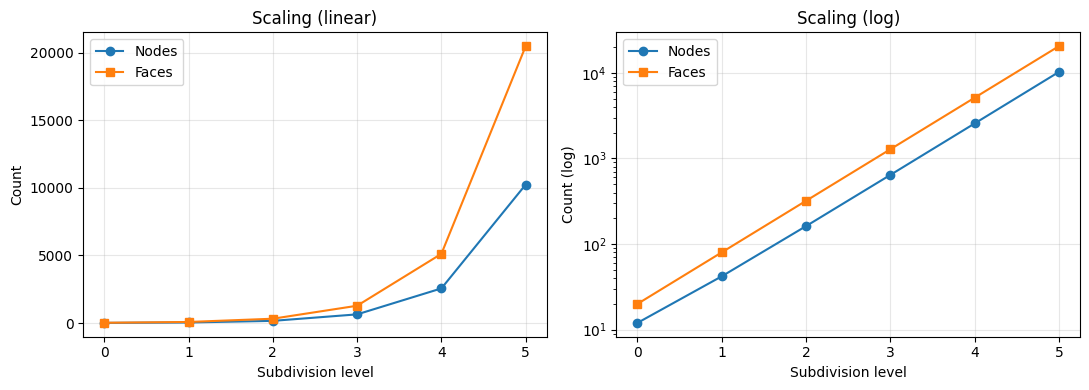

Growth rate (nodes):
  Level 0 -> 1: 3.50× (theoretical: 4×)
  Level 1 -> 2: 3.86× (theoretical: 4×)
  Level 2 -> 3: 3.96× (theoretical: 4×)
  Level 3 -> 4: 3.99× (theoretical: 4×)
  Level 4 -> 5: 4.00× (theoretical: 4×)


In [40]:
subdivisions = np.arange(0, 6)
node_counts, face_counts = [], []
for s in subdivisions:
    v, f = generate_icosahedral_mesh(refinement_level=int(s))
    node_counts.append(len(v))
    face_counts.append(len(f))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(subdivisions, node_counts, "o-", label="Nodes")
ax1.plot(subdivisions, face_counts, "s-", label="Faces")
ax1.set_xlabel("Subdivision level")
ax1.set_ylabel("Count")
ax1.set_title("Scaling (linear)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.semilogy(subdivisions, node_counts, "o-", label="Nodes")
ax2.semilogy(subdivisions, face_counts, "s-", label="Faces")
ax2.set_xlabel("Subdivision level")
ax2.set_ylabel("Count (log)")
ax2.set_title("Scaling (log)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Growth rate (nodes):")
for i in range(1, len(subdivisions)):
    ratio = node_counts[i] / node_counts[i - 1]
    print(f"  Level {i-1} -> {i}: {ratio:.2f}× (theoretical: 4×)")